# **Data Understanding And Cleaning**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

In [17]:
fear_greed = pd.read_csv(r"csv_files\fear_greed_index.csv")
his_data = pd.read_csv(r"csv_files\historical_data.csv")

In [85]:
his_data.shape , fear_greed.shape

((211224, 8), (2644, 2))

## **Fear Greed Data**

In [19]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [20]:
#Check value counts for classification Column
fear_greed['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [21]:
# shape of date and dataset (check if there is same date or Not)
fear_greed['date'].value_counts().shape , fear_greed.shape

((2644,), (2644, 4))

In [22]:
# Check wheather to keep value Column or not
fear_greed[['value' , 'classification']].groupby('classification').mean()

,value
classification,
Extreme Fear,18.27
Extreme Greed,82.12
Fear,34.18
Greed,65.85
Neutral,49.96


* Drop the value Colums as classification column give better understanding of fear and Greed
* TimeStamp Col is not required as we have date Column , because unix timestamp does not add any extra insight.

In [23]:
fear_greed.drop(columns=['value' , 'timestamp'] , inplace=True) # Drop the Columns

In [24]:
fear_greed.head()

,classification,date
0,Fear,2018-02-01
1,Extreme Fear,2018-02-02
2,Fear,2018-02-03
3,Extreme Fear,2018-02-04
4,Extreme Fear,2018-02-05


## **Trader Data  : his_data**

In [87]:
his_data.head(3)

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Fee,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"7,872.16",BUY,02-12-2024 22:50,0.00,0.35,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,127.68,BUY,02-12-2024 22:50,0.00,0.01,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,150.63",BUY,02-12-2024 22:50,0.00,0.05,2024-12-02


In [27]:
for col in his_data.columns:
    print(f"\n===== {col} =====")
    print(his_data[col].value_counts())



===== Account =====
Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x92f17e8d81a944691c10e753af1b1baae

In [28]:
his_data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [29]:
his_data = his_data.drop(columns=[
    "Execution Price",
    "Size Tokens",
    "Start Position",
    "Direction",
    "Transaction Hash",
    "Order ID",
    "Trade ID",
    "Crossed",
    "Timestamp"
])


**Columns Retained**

**Account**
Identifies individual traders and enables trader-level behavior and performance analysis.

**Coin**
Specifies the traded asset and prevents mixing performance across different instruments.

**Side**
Indicates trade direction (BUY/SELL), useful for understanding behavioral bias under different market sentiments.

**Timestamp IS**T
Provides the exact execution time of trades and is used to derive the trading date required for merging with the Fear–Greed dataset.

**Size USD**
Represents the monetary size of each trade and acts as a proxy for risk exposure.

**Closed PnL**
Captures the final realized profit or loss of each trade and is the primary metric for evaluating trader performance.

**Fee**
Accounts for transaction costs, which directly impact net profitability.



**Columns Dropped**

**Timestamp (Unix)**
Redundant with Timestamp IST and offers no additional analytical value.

**Execution Price**
Trade outcome is already reflected in Closed PnL; price-level analysis is outside the scope of this assignment.

**Size Tokens**
Duplicates trade size information already represented in standardized USD terms.

**Start Position**
Intermediate state information that does not affect final profitability or sentiment-level behavior analysis.

**Direction**
Duplicates the information provided by the Side column.

**Transaction Hash, Order ID, Trade ID**
Technical identifiers used for system tracking, not relevant for behavioral or performance analysis.

**Crossed**
Execution-level microstructure detail with no impact on sentiment-driven trading behavior.

In [30]:
his_data.head()

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Fee
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"7,872.16",BUY,02-12-2024 22:50,0.00,0.35
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,127.68,BUY,02-12-2024 22:50,0.00,0.01
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,150.63",BUY,02-12-2024 22:50,0.00,0.05
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,142.04",BUY,02-12-2024 22:50,0.00,0.05
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,69.75,BUY,02-12-2024 22:50,0.00,0.00


## **Merging Both Datasets**

In [31]:
his_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Account        211224 non-null  object 
 1   Coin           211224 non-null  object 
 2   Size USD       211224 non-null  float64
 3   Side           211224 non-null  object 
 4   Timestamp IST  211224 non-null  object 
 5   Closed PnL     211224 non-null  float64
 6   Fee            211224 non-null  float64
dtypes: float64(3), object(4)
memory usage: 11.3+ MB


In [32]:
his_data["trade_date"] = pd.to_datetime(
    his_data["Timestamp IST"], dayfirst=True
).dt.date
his_data.head()

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Fee,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"7,872.16",BUY,02-12-2024 22:50,0.00,0.35,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,127.68,BUY,02-12-2024 22:50,0.00,0.01,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,150.63",BUY,02-12-2024 22:50,0.00,0.05,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,142.04",BUY,02-12-2024 22:50,0.00,0.05,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,69.75,BUY,02-12-2024 22:50,0.00,0.00,2024-12-02


In [33]:
fear_greed["date"] = pd.to_datetime(fear_greed["date"]).dt.date  # Ensure date type matches.
fear_greed.head()

,classification,date
0,Fear,2018-02-01
1,Extreme Fear,2018-02-02
2,Fear,2018-02-03
3,Extreme Fear,2018-02-04
4,Extreme Fear,2018-02-05


In [34]:
trader_sentiment_df = his_data.merge(
    fear_greed[["date", "classification"]],
    left_on="trade_date",
    right_on="date",
    how="inner"
) # perform Inner JOin

In [35]:
trader_sentiment_df.head()

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Fee,trade_date,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"7,872.16",BUY,02-12-2024 22:50,0.00,0.35,2024-12-02,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,127.68,BUY,02-12-2024 22:50,0.00,0.01,2024-12-02,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,150.63",BUY,02-12-2024 22:50,0.00,0.05,2024-12-02,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,142.04",BUY,02-12-2024 22:50,0.00,0.05,2024-12-02,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,69.75,BUY,02-12-2024 22:50,0.00,0.00,2024-12-02,2024-12-02,Extreme Greed


In [88]:
trader_sentiment_df.to_csv("csv_files/trader_sentiment_df.csv")

# **Data Preprocessing**

In [36]:
# Check missing values
trader_sentiment_df.isna().sum()


Account           0
Coin              0
Size USD          0
Side              0
Timestamp IST     0
Closed PnL        0
Fee               0
trade_date        0
date              0
classification    0
dtype: int64

In [37]:
# Check Duplicate rows
trader_sentiment_df.duplicated().sum()

np.int64(22002)

In [38]:
trader_sentiment_df[trader_sentiment_df.duplicated(keep=False)]

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Fee,trade_date,date,classification
52,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"4,520.00",SELL,03-12-2024 14:39,606.33,1.58,2024-12-03,2024-12-03,Extreme Greed
53,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"4,520.00",SELL,03-12-2024 14:39,606.33,1.58,2024-12-03,2024-12-03,Extreme Greed
174,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,19.29,SELL,03-12-2024 23:38,0.65,0.01,2024-12-03,2024-12-03,Extreme Greed
176,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,19.29,SELL,03-12-2024 23:38,0.65,0.01,2024-12-03,2024-12-03,Extreme Greed
178,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AAVE,19.29,SELL,03-12-2024 23:38,0.65,0.01,2024-12-03,2024-12-03,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...
211200,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,"4,012.59",SELL,25-04-2025 15:35,-193.16,0.40,2025-04-25,2025-04-25,Greed
211201,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,"4,012.59",SELL,25-04-2025 15:35,-193.16,0.40,2025-04-25,2025-04-25,Greed
211202,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,"3,963.38",SELL,25-04-2025 15:35,-190.79,0.40,2025-04-25,2025-04-25,Greed
211206,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,"3,427.74",SELL,25-04-2025 15:35,-165.00,0.34,2025-04-25,2025-04-25,Greed


In [39]:
# remove duplicat data
trader_sentiment_df = trader_sentiment_df.drop_duplicates()
trader_sentiment_df.duplicated().sum()

np.int64(0)

In [40]:
trader_sentiment_df.dtypes

Account            object
Coin               object
Size USD          float64
Side               object
Timestamp IST      object
Closed PnL        float64
Fee               float64
trade_date         object
date               object
classification     object
dtype: object

In [41]:
trader_sentiment_df = trader_sentiment_df.assign(
    **{"Timestamp IST": pd.to_datetime(trader_sentiment_df["Timestamp IST"], dayfirst=True),
       "trade_date": pd.to_datetime(trader_sentiment_df["trade_date"])}
)

In [42]:
trader_sentiment_df.dtypes

Account                   object
Coin                      object
Size USD                 float64
Side                      object
Timestamp IST     datetime64[ns]
Closed PnL               float64
Fee                      float64
trade_date        datetime64[ns]
date                      object
classification            object
dtype: object

In [43]:
#check classification Cols
trader_sentiment_df["classification"].value_counts()


classification
Fear             53815
Greed            46385
Extreme Greed    37390
Neutral          33413
Extreme Fear     18213
Name: count, dtype: int64

In [44]:
#describe Colsed PNL Column
trader_sentiment_df["Closed PnL"].describe()


count    189,216.00
mean          51.35
std          966.27
min     -117,990.10
25%            0.00
50%            0.00
75%            6.36
max      135,329.09
Name: Closed PnL, dtype: float64

# **EDA**

## **Metrics Computation**

is_win: True if the trade ended in profit (Closed PnL > 0), else False (loss or breakeven)
* True → profitable trade

* False → loss or zero PnL

In [45]:
# is_win column
trader_sentiment_df["is_win"] = trader_sentiment_df["Closed PnL"] > 0
trader_sentiment_df.head()

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Fee,trade_date,date,classification,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"7,872.16",BUY,2024-12-02 22:50:00,0.00,0.35,2024-12-02,2024-12-02,Extreme Greed,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,127.68,BUY,2024-12-02 22:50:00,0.00,0.01,2024-12-02,2024-12-02,Extreme Greed,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,150.63",BUY,2024-12-02 22:50:00,0.00,0.05,2024-12-02,2024-12-02,Extreme Greed,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,142.04",BUY,2024-12-02 22:50:00,0.00,0.05,2024-12-02,2024-12-02,Extreme Greed,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,69.75,BUY,2024-12-02 22:50:00,0.00,0.00,2024-12-02,2024-12-02,Extreme Greed,False


In [46]:
sentiment_metrics = (
    trader_sentiment_df
    .groupby("classification")
    .agg(
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        trade_count=("Closed PnL", "count"),
        win_rate=("is_win", "mean"),
        avg_trade_size_usd=("Size USD", "mean"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)
# set win rate col to percentage
sentiment_metrics["win_rate"] = sentiment_metrics["win_rate"] * 100
sentiment_metrics

,classification,total_pnl,avg_pnl,trade_count,win_rate,avg_trade_size_usd,total_fees
0,Extreme Fear,"714,307.06",39.22,18213,37.76,"6,021.44","23,013.04"
1,Extreme Greed,"2,640,896.52",70.63,37390,45.20,"3,228.58","26,506.97"
2,Fear,"3,117,866.77",57.94,53815,41.60,"8,662.42","89,447.56"
3,Greed,"2,016,771.65",43.48,46385,38.16,"6,094.86","62,180.26"
4,Neutral,"1,226,597.30",36.71,33413,39.36,"5,187.75","38,453.60"


In [47]:
"""sentiment_metrics.to_csv(
    "csv_files/sentiment_metrics.csv",
    index=False
)"""

'sentiment_metrics.to_csv(\n    "csv_files/sentiment_metrics.csv",\n    index=False\n)'

### * barChart - Total PNL VS Sentiment

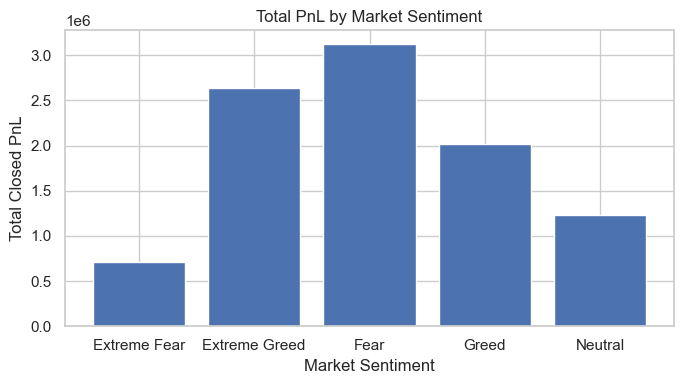

In [48]:
plt.figure(figsize=(7,4))
plt.bar(
    sentiment_metrics["classification"],
    sentiment_metrics["total_pnl"]
)
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.title("Total PnL by Market Sentiment")
plt.tight_layout()
#plt.savefig("outputs/total_pnl_by_sentiment.png")
plt.show()

<Figure size 700x400 with 0 Axes>

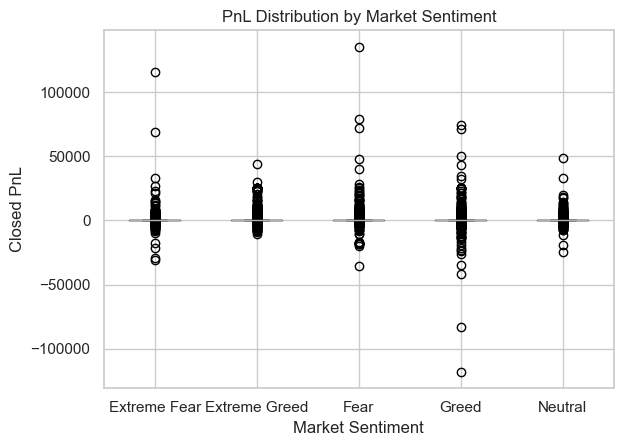

In [49]:
plt.figure(figsize=(7,4))
trader_sentiment_df.boxplot(
    column="Closed PnL",
    by="classification"
)
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.title("PnL Distribution by Market Sentiment")
plt.suptitle("")  # remove auto title
plt.tight_layout()
#plt.savefig("outputs/pnl_distribution_by_sentiment.png")
plt.show()

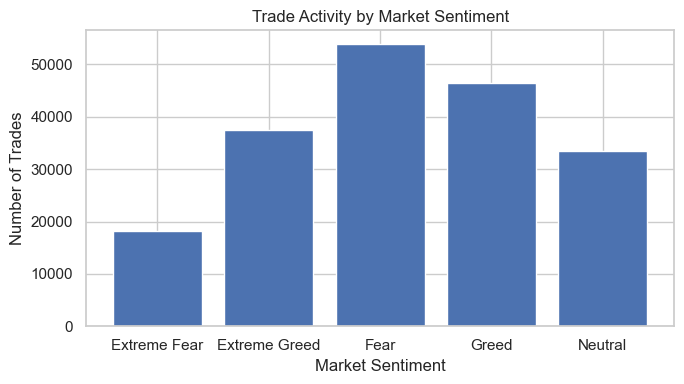

In [50]:
plt.figure(figsize=(7,4))
plt.bar(
    sentiment_metrics["classification"],
    sentiment_metrics["trade_count"]
)
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.title("Trade Activity by Market Sentiment")
plt.tight_layout()
#plt.savefig("outputs/trade_count_by_sentiment.png")
plt.show()

## **sentiment-level → trader & coin-level behavior.**

In [51]:
trader_sentiment_df["Coin"].value_counts()


Coin
HYPE    61155
@107    27816
BTC     21491
SOL      9273
ETH      8888
        ...  
@18         1
@30         1
@25         1
@86         1
@68         1
Name: count, Length: 246, dtype: int64

This table answers:

Which coin performs best in Greed?

Which coin bleeds in Fear?

Where risk is highest?

In [52]:
coin_sentiment_metrics = (
    trader_sentiment_df
    .groupby(["Coin", "classification"])
    .agg(
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        trade_count=("Closed PnL", "count"),
        avg_trade_size_usd=("Size USD", "mean"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)
"""
coin_sentiment_metrics.to_csv(
    "csv_files/coin_sentiment_metrics.csv",
    index=False
)
"""
coin_sentiment_metrics

,Coin,classification,total_pnl,avg_pnl,trade_count,avg_trade_size_usd,total_fees
0,@1,Extreme Greed,480.26,18.47,26,120.91,0.44
1,@1,Fear,0.00,0.00,1,0.58,0.00
2,@1,Greed,1.08,0.18,6,83.05,0.15
3,@10,Extreme Fear,-0.06,-0.03,2,18.63,0.01
4,@10,Fear,0.00,0.00,1,0.00,0.00
...,...,...,...,...,...,...,...
719,kSHIB,Extreme Fear,0.00,0.00,1,221.96,0.08
720,kSHIB,Extreme Greed,264.97,8.83,30,"2,717.71",20.89
721,kSHIB,Fear,13.64,13.64,1,208.31,0.07
722,kSHIB,Greed,0.00,0.00,3,481.37,0.41


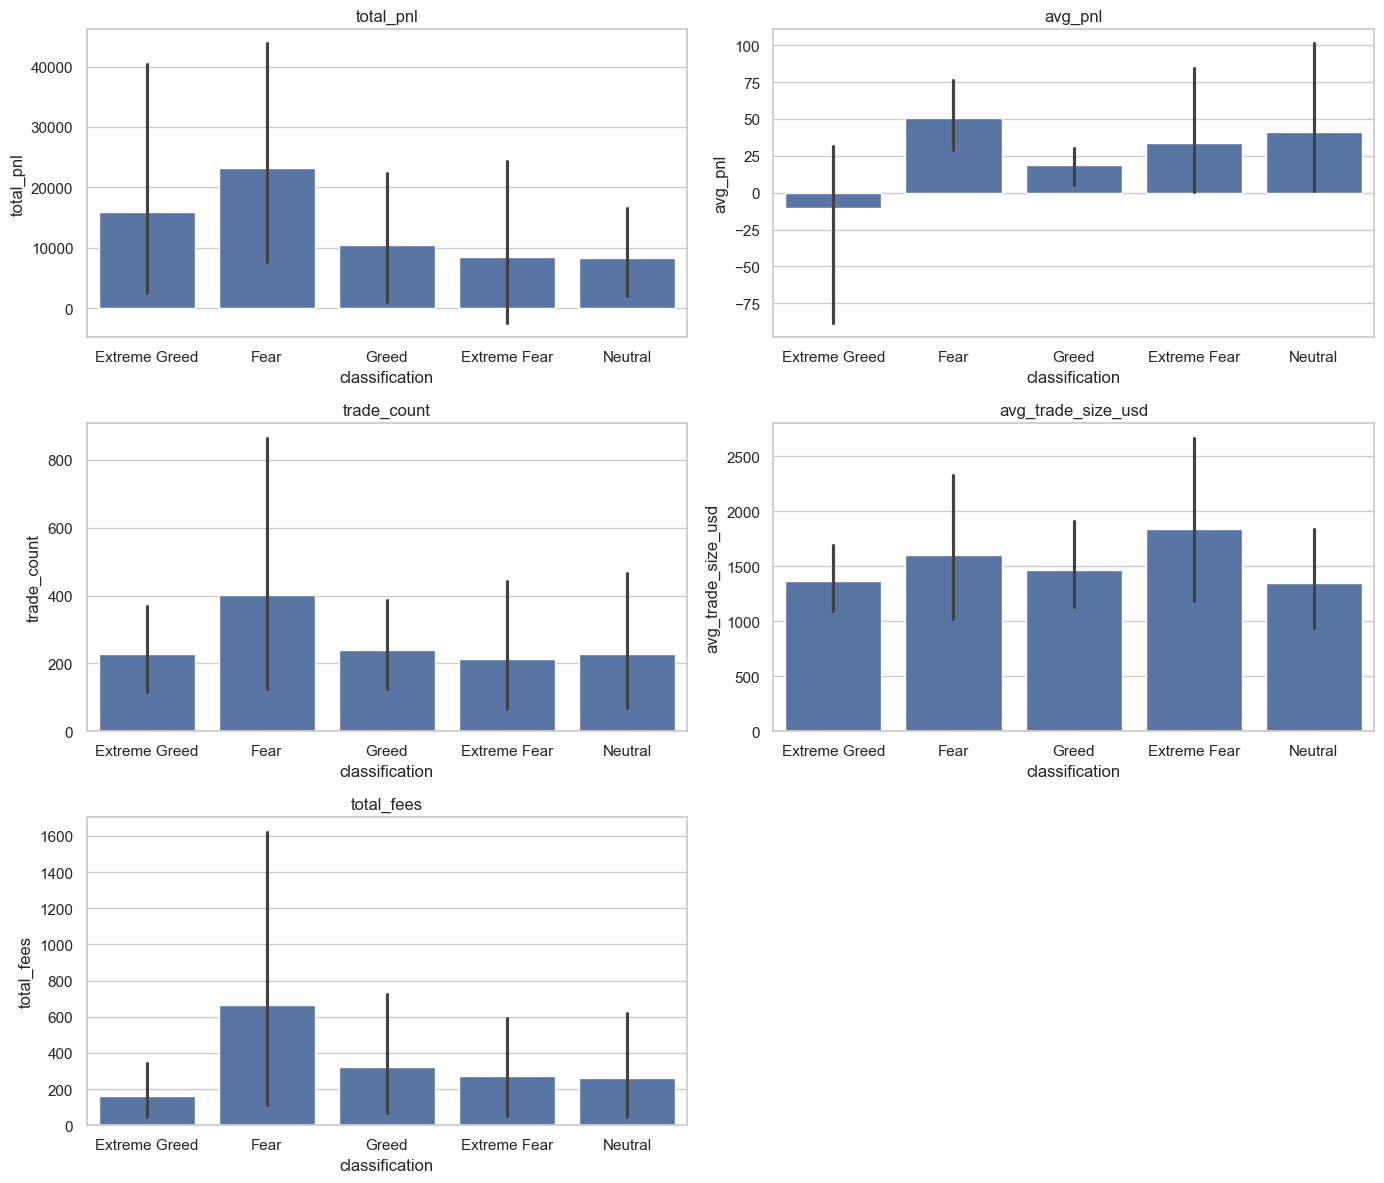

In [53]:
metrics = [
    "total_pnl",
    "avg_pnl",
    "trade_count",
    "avg_trade_size_usd",
    "total_fees"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(
        x="classification",
        y=metric,
        data=coin_sentiment_metrics,
        ax=axes[i]
    )
    axes[i].set_title(metric)

# Remove empty subplot (since 5 plots, 6 slots)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

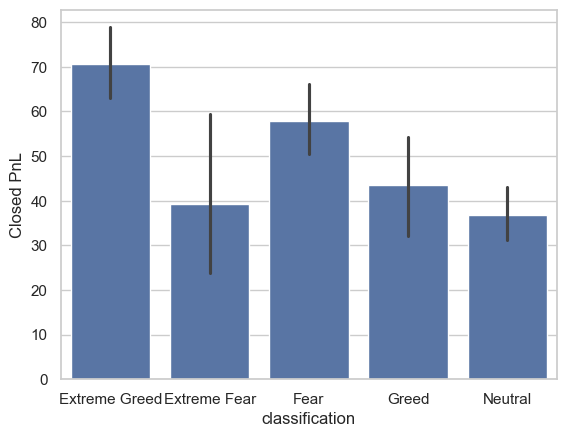

In [54]:
sns.barplot(
    x="classification",
    y="Closed PnL",
    #hue="Coin",
    data=trader_sentiment_df
)
plt.show()

## **Risk behavior per coin**

What this shows
* Which coins traders size up during Greed
* Which coins traders avoid during Fear

In [55]:
coin_risk = (
    trader_sentiment_df.
    groupby(["Coin" , "classification"])["Size USD"]
    .mean()
    .reset_index(name = "avg_trade_size_usd")
)
coin_risk

,Coin,classification,avg_trade_size_usd
0,@1,Extreme Greed,120.91
1,@1,Fear,0.58
2,@1,Greed,83.05
3,@10,Extreme Fear,18.63
4,@10,Fear,0.00
...,...,...,...
719,kSHIB,Extreme Fear,221.96
720,kSHIB,Extreme Greed,"2,717.71"
721,kSHIB,Fear,208.31
722,kSHIB,Greed,481.37


**Trader-level behavior per coin**

Trader × Coin × Sentiment

Traders who are coin specialists

Traders who lose money emotionally on specific coins

In [56]:
trader_coin_metrics = (
    trader_sentiment_df
    .groupby(["Account", "Coin", "classification"])
    .agg(
        total_pnl=("Closed PnL", "sum"),
        trade_count=("Closed PnL", "count"),
        avg_trade_size_usd=("Size USD", "mean")
    )
    .reset_index()
)
trader_coin_metrics

,Account,Coin,classification,total_pnl,trade_count,avg_trade_size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,Extreme Fear,"119,258.28",66,"22,027.34"
1,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,Extreme Greed,"-73,711.92",322,"19,043.21"
2,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,Fear,"702,587.73",969,"27,401.15"
3,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,Greed,"-118,317.20",170,"31,716.04"
4,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,Neutral,"120,834.71",317,"29,400.16"
...,...,...,...,...,...,...
1695,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,Fear,"25,059.80",9622,"1,510.73"
1696,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,Greed,"22,225.26",2267,"1,731.15"
1697,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,Neutral,"19,221.00",6430,"1,681.70"
1698,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,MELANIA,Extreme Greed,"-4,249.64",81,712.36


In [57]:
"""trader_coin_metrics.to_csv(
    "csv_files/trader_coin_metrics.csv",
    index=False
)"""

'trader_coin_metrics.to_csv(\n    "csv_files/trader_coin_metrics.csv",\n    index=False\n)'

In [58]:
trader_sentiment_df['classification'].value_counts()

classification
Fear             53815
Greed            46385
Extreme Greed    37390
Neutral          33413
Extreme Fear     18213
Name: count, dtype: int64

## **PnL and dataTime Sentiment**

In [59]:
daily_pnl_sentiment = (
    trader_sentiment_df
    .groupby(["trade_date", "classification"])["Closed PnL"]
    .sum()
    .reset_index()
)
daily_pnl_sentiment

,trade_date,classification,Closed PnL
0,2023-05-01,Greed,0.00
1,2023-12-05,Extreme Greed,0.00
2,2023-12-14,Greed,-205.43
3,2023-12-15,Greed,-24.63
4,2023-12-16,Greed,0.00
...,...,...,...
474,2025-04-27,Greed,"2,685.46"
475,2025-04-28,Neutral,"36,772.93"
476,2025-04-29,Greed,"123,054.48"
477,2025-04-30,Greed,"12,929.17"


In [60]:
trader_sentiment_df["year"] = trader_sentiment_df["trade_date"].dt.year
yearly_pnl_sentiment = (
    trader_sentiment_df
    .groupby(["year", "classification"])["Closed PnL"]
    .sum()
    .reset_index()
)


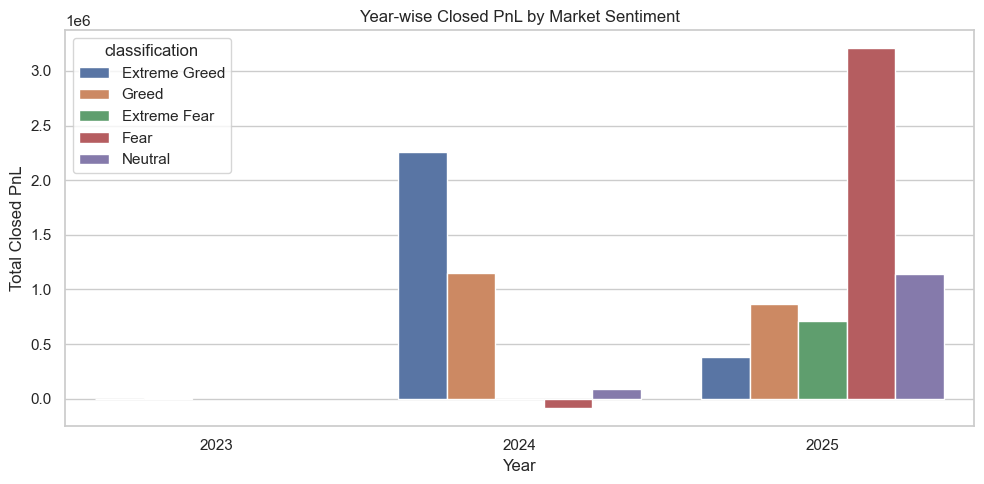

In [61]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=yearly_pnl_sentiment,
    x="year",
    y="Closed PnL",
    hue="classification"
)

plt.title("Year-wise Closed PnL by Market Sentiment")
plt.xlabel("Year")
plt.ylabel("Total Closed PnL")
plt.tight_layout()
#plt.savefig("outputs/yearly_pnl_by_sentiment_bar.png")
plt.show()


# **BaseLine Analysis**

In [62]:
# is_win column
trader_sentiment_df["is_win"] = trader_sentiment_df["Closed PnL"] > 0
trader_sentiment_df.head()

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Fee,trade_date,date,classification,is_win,year
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"7,872.16",BUY,2024-12-02 22:50:00,0.00,0.35,2024-12-02,2024-12-02,Extreme Greed,False,2024
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,127.68,BUY,2024-12-02 22:50:00,0.00,0.01,2024-12-02,2024-12-02,Extreme Greed,False,2024
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,150.63",BUY,2024-12-02 22:50:00,0.00,0.05,2024-12-02,2024-12-02,Extreme Greed,False,2024
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,"1,142.04",BUY,2024-12-02 22:50:00,0.00,0.05,2024-12-02,2024-12-02,Extreme Greed,False,2024
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,69.75,BUY,2024-12-02 22:50:00,0.00,0.00,2024-12-02,2024-12-02,Extreme Greed,False,2024


## Behaviour Vs Sentiment

---







1. Do Traders trade more in Fear or Greed?
2. Do They make money
3. Do they take more risk
4. Is higher activity actually Profitable?

In [63]:
# define win once

final_summary = (
    trader_sentiment_df
    .groupby("classification")
    .agg(
        trade_count=("Closed PnL", "size"),
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        win_count=("is_win", "sum"),
        risk_exposure=("Size USD", "mean"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)

# loss_count
final_summary["loss_count"] = (
    final_summary["trade_count"] - final_summary["win_count"]
)
final_summary["avg_trade_count_pct"] = (
    final_summary["trade_count"] / final_summary["trade_count"].sum()
) * 100


final_summary["win_rate"] = (
    final_summary["win_count"] / final_summary["trade_count"]
)* 100
# sort by money made
final_summary = final_summary.sort_values(by="total_pnl", ascending=False)

final_summary = final_summary[["classification","trade_count","total_pnl", "avg_pnl","win_count","loss_count","win_rate","risk_exposure","total_fees"]]
final_summary

,classification,trade_count,total_pnl,avg_pnl,win_count,loss_count,win_rate,risk_exposure,total_fees
2,Fear,53815,"3,117,866.77",57.94,22385,31430,41.60,"8,662.42","89,447.56"
1,Extreme Greed,37390,"2,640,896.52",70.63,16899,20491,45.20,"3,228.58","26,506.97"
3,Greed,46385,"2,016,771.65",43.48,17701,28684,38.16,"6,094.86","62,180.26"
4,Neutral,33413,"1,226,597.30",36.71,13153,20260,39.36,"5,187.75","38,453.60"
0,Extreme Fear,18213,"714,307.06",39.22,6878,11335,37.76,"6,021.44","23,013.04"


#  **Distribution & Risk Analysis**
* Are losses heavier than profits?

* Does sentiment increase volatility?

* Are traders overtrading (fees killing PnL)?

* Is risk rewarded or punished?

### Profit vs loss Distribution

In [64]:
trader_sentiment_df["pnl_label"] = np.where(
    trader_sentiment_df["Closed PnL"] > 0,
    "Profit",
    "Loss"
)
profit_loss_dist = (
    trader_sentiment_df
    .groupby(["classification", "pnl_label"])
    .size()
    .reset_index(name="trade_count")
)
profit_loss_dist["total_trade_count_pnl"] = (
    profit_loss_dist
    .groupby("classification")["trade_count"]
    .transform("sum")
)
profit_loss_dist["win_loss_%"] = profit_loss_dist["trade_count"] / profit_loss_dist["total_trade_count_pnl"] * 100
profit_loss_dist

,classification,pnl_label,trade_count,total_trade_count_pnl,win_loss_%
0,Extreme Fear,Loss,11335,18213,62.24
1,Extreme Fear,Profit,6878,18213,37.76
2,Extreme Greed,Loss,20491,37390,54.80
3,Extreme Greed,Profit,16899,37390,45.20
4,Fear,Loss,31430,53815,58.40
5,Fear,Profit,22385,53815,41.60
6,Greed,Loss,28684,46385,61.84
7,Greed,Profit,17701,46385,38.16
8,Neutral,Loss,20260,33413,60.64
9,Neutral,Profit,13153,33413,39.36


### PnL spread & volatility (core risk signal)

In [65]:
pnl_distribution = (
    trader_sentiment_df
    .groupby("classification")["Closed PnL"]
    .describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .reset_index()
)
pnl_distribution


,classification,mean,std,min,25%,50%,75%,max
0,Extreme Fear,39.22,"1,230.71","-31,036.69",0.00,0.00,7.39,"115,287.00"
1,Extreme Greed,70.63,790.66,"-10,259.47",0.00,0.00,9.86,"44,223.45"
2,Fear,57.94,996.73,"-35,681.75",0.00,0.00,6.21,"135,329.09"
3,Greed,43.48,"1,158.34","-117,990.10",0.00,0.00,5.21,"74,530.52"
4,Neutral,36.71,546.58,"-24,500.00",0.00,0.00,4.59,"48,504.10"


### Fee drag analysis (overtrading detector)

Interpretation

* High ratio → profits eaten by fees

* Common in Greed → too many low-quality trades

In [66]:
fee_pnl_summary = (
    trader_sentiment_df
    .groupby("classification")
    .agg(
        total_pnl=("Closed PnL", "sum"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)
fee_pnl_summary["fee_pnl_ratio"] = (
    fee_pnl_summary["total_fees"] / fee_pnl_summary["total_pnl"].abs()
)
fee_pnl_summary


,classification,total_pnl,total_fees,fee_pnl_ratio
0,Extreme Fear,"714,307.06","23,013.04",0.03
1,Extreme Greed,"2,640,896.52","26,506.97",0.01
2,Fear,"3,117,866.77","89,447.56",0.03
3,Greed,"2,016,771.65","62,180.26",0.03
4,Neutral,"1,226,597.30","38,453.60",0.03


### Risk vs Reward check

Higher = better use of risk.

Negative = capital is being punished

In [67]:
risk_reward = (
    trader_sentiment_df
    .groupby("classification", as_index=False)
    .agg(
        total_pnl=("Closed PnL", "sum"),
        total_risk_usd=("Size USD", "sum")
    )
)

risk_reward["pnl_per_usd_risk%"] = (
    risk_reward["total_pnl"] / risk_reward["total_risk_usd"]
)*100

risk_reward = risk_reward[["classification", "pnl_per_usd_risk%"]]

risk_reward


,classification,pnl_per_usd_risk%
0,Extreme Fear,0.65
1,Extreme Greed,2.19
2,Fear,0.67
3,Greed,0.71
4,Neutral,0.71


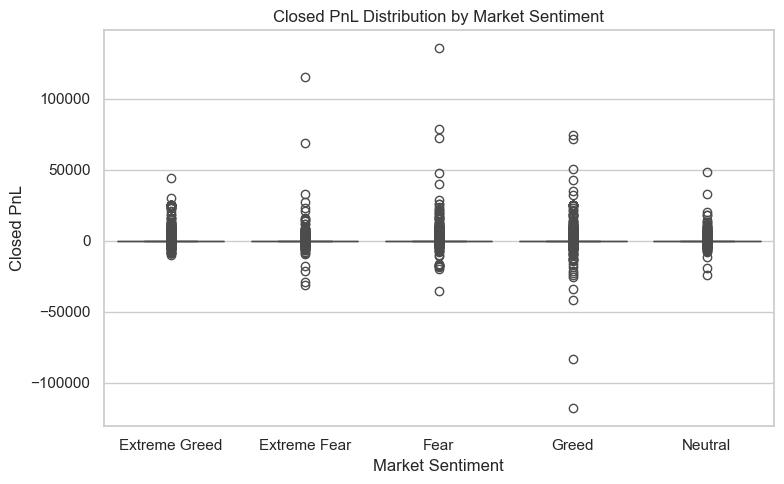

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=trader_sentiment_df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.tight_layout()
#plt.savefig("outputs/pnl_distribution_boxplot.png")
plt.show()


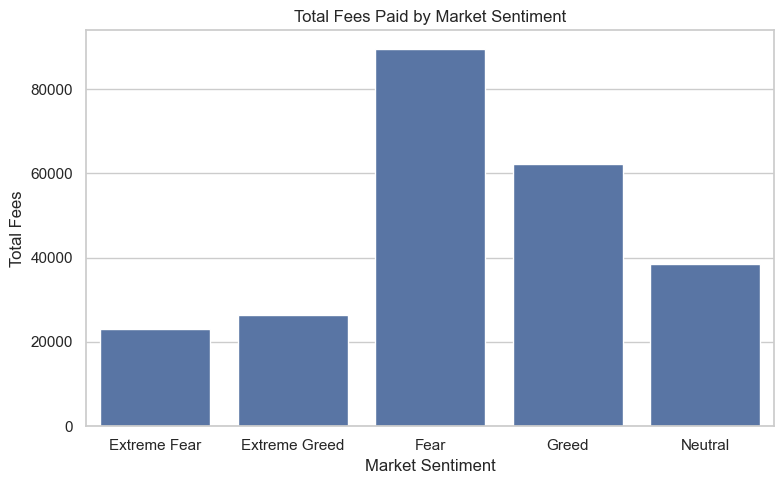

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=fee_pnl_summary,
    x="classification",
    y="total_fees"
)

plt.title("Total Fees Paid by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Fees")
plt.tight_layout()
#plt.savefig("outputs/fees_by_sentiment.png")
plt.show()


# **Coin-level Sensitivity & Risk Concentration**
Which coins make or lose money in Fear vs Greed?

Which coins attract higher risk (bigger trade sizes)?

Are losses concentrated in specific coins?

Which coins are sentiment-agnostic (stable)?

### Coin × Sentiment performance table

In [70]:
coin_sentiment_perf = (
    trader_sentiment_df
    .groupby(["Coin", "classification"])
    .agg(
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        trade_count=("Closed PnL", "count"),
        avg_trade_size_usd=("Size USD", "mean"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)

coin_sentiment_perf


,Coin,classification,total_pnl,avg_pnl,trade_count,avg_trade_size_usd,total_fees
0,@1,Extreme Greed,480.26,18.47,26,120.91,0.44
1,@1,Fear,0.00,0.00,1,0.58,0.00
2,@1,Greed,1.08,0.18,6,83.05,0.15
3,@10,Extreme Fear,-0.06,-0.03,2,18.63,0.01
4,@10,Fear,0.00,0.00,1,0.00,0.00
...,...,...,...,...,...,...,...
719,kSHIB,Extreme Fear,0.00,0.00,1,221.96,0.08
720,kSHIB,Extreme Greed,264.97,8.83,30,"2,717.71",20.89
721,kSHIB,Fear,13.64,13.64,1,208.31,0.07
722,kSHIB,Greed,0.00,0.00,3,481.37,0.41


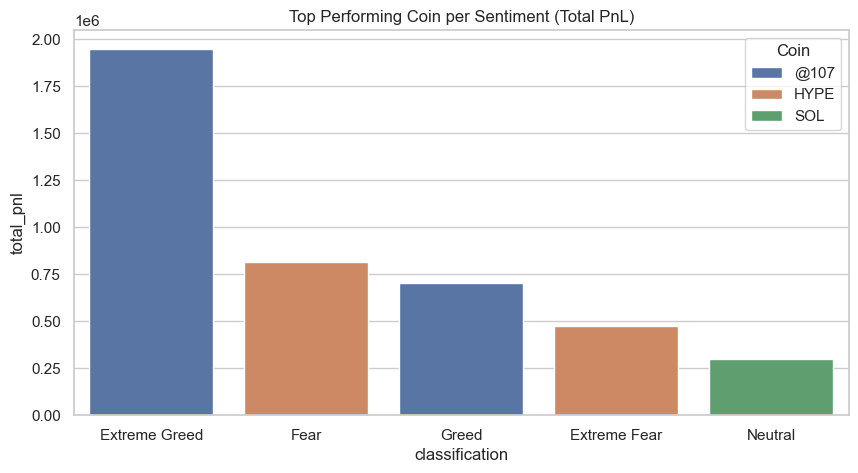

In [71]:
# Top performing coin per sentiment (by total PnL)
top_coin_per_sentiment = (
    coin_sentiment_perf
    .sort_values("total_pnl", ascending=False)
    .groupby("classification")
    .head(1)
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_coin_per_sentiment,
    x="classification",
    y="total_pnl",
    hue="Coin"
)
plt.title("Top Performing Coin per Sentiment (Total PnL)")
plt.show()


### Risk Connection per Coin

In [72]:
coin_risk_concentration = (
    trader_sentiment_df
    .groupby(["Coin", "classification"])
    .agg(
        total_risk_usd=("Size USD", "sum"),
        total_pnl = ("Closed PnL" , "sum")
    )
    .reset_index()
    #.sort_values(by = "total_risk_usd" , ascending = False)
)
coin_risk_concentration["efficiency%"] = (
    coin_risk_concentration["total_pnl"] / coin_risk_concentration["total_risk_usd"]
) * 100
coin_risk_concentration = coin_risk_concentration.sort_values(by = "total_risk_usd" , ascending = False)
coin_risk_concentration.head(20)

,Coin,classification,total_risk_usd,total_pnl,efficiency%
264,BTC,Fear,"291,390,764.59","460,670.67",0.16
265,BTC,Greed,"161,499,637.52","107,508.13",0.07
266,BTC,Neutral,"94,070,921.77","158,797.05",0.17
374,HYPE,Fear,"61,314,536.53","815,469.81",1.33
585,SOL,Fear,"49,774,353.25","674,006.78",1.35
263,BTC,Extreme Greed,"43,227,030.19","98,707.61",0.23
312,ETH,Fear,"37,209,528.33","604,505.28",1.62
313,ETH,Greed,"36,351,201.40","312,247.58",0.86
262,BTC,Extreme Fear,"34,870,328.49",668.08,0.00
372,HYPE,Extreme Fear,"28,409,354.71","473,147.21",1.67


row 1 : For every `$1` risked in BTC during Fear, traders earned `$0.0016`

row 4 : For every `$1` risked in HYPE during Fear , traders earned `$0.0133`

here are the best and worse performing Coins based on each sentiment


In [73]:
best_coin_per_sentiment = (
    coin_risk_concentration
    .sort_values("efficiency%", ascending=False)
    .groupby("classification")
    .head(5)
    .reset_index(drop=True)
)

best_coin_per_sentiment.sort_values(by = "classification" , ascending = False)

,Coin,classification,total_risk_usd,total_pnl,efficiency%
24,USUAL,Neutral,"6,938.77",697.08,10.05
23,ZRO,Neutral,"165,862.93","36,172.38",21.81
20,@138,Neutral,50.78,19.53,38.46
19,DOGE,Neutral,"298,882.07","115,809.47",38.75
1,AVAX,Neutral,"20,385.83","22,827.49",111.98
3,@109,Greed,"5,430.19","5,410.85",99.64
4,@112,Greed,14.44,14.33,99.27
5,@114,Greed,1.32,1.31,99.17
6,@103,Greed,4.54,4.49,99.00
7,@116,Greed,1.49,1.47,98.87


In [74]:
worst_coin_per_sentiment = (
    coin_risk_concentration
    .sort_values("efficiency%", ascending=True)
    .groupby("classification")
    .head(5)
    .reset_index(drop=True)
)

worst_coin_per_sentiment

,Coin,classification,total_risk_usd,total_pnl,efficiency%
0,@135,Extreme Greed,15.56,"-5,981.36","-38,440.64"
1,@83,Neutral,49.07,"-1,044.79","-2,129.18"
2,@147,Greed,612.56,-350.63,-57.24
3,GRIFFAIN,Extreme Fear,852.13,-378.09,-44.37
4,@125,Greed,247.40,-104.38,-42.19
5,@83,Greed,122.64,-42.84,-34.93
6,@63,Greed,59.95,-20.66,-34.47
7,WIF,Fear,"10,925.94","-3,326.85",-30.45
8,TRUMP,Greed,"1,703,676.66","-433,030.84",-25.42
9,@95,Extreme Greed,120.78,-29.44,-24.37


# Travel Level Consistency

### Trader performance by sentiment

In [75]:
trader_sentiment_perf = (
    trader_sentiment_df
    .groupby(["Account", "classification"])
    .agg(
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        trade_count=("Closed PnL", "count"),
        win_rate=("is_win", "mean"),
        avg_trade_size_usd=("Size USD", "mean"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)

trader_sentiment_perf["win_rate"] *= 100
trader_sentiment_perf.sort_values(["total_pnl"], ascending=False)


,Account,classification,total_pnl,avg_pnl,trade_count,win_rate,avg_trade_size_usd,total_fees
135,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,"1,086,826.23",701.18,1550,49.94,"3,304.93","1,515.76"
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,"1,000,928.04",889.71,1125,54.31,"24,913.26","3,076.10"
143,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,"603,522.11",56.94,10599,49.45,"3,714.34","5,430.60"
137,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,"524,507.09",96.38,5442,26.88,"6,600.99","8,030.28"
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,"461,000.67",76.64,6015,57.14,"2,673.46","1,641.40"
...,...,...,...,...,...,...,...,...
65,0x513b8629fe877bb581bf244e326a047b249c4ff1,Extreme Fear,"-71,224.29",-273.94,260,37.69,"11,465.23",474.37
30,0x39cef799f8b69da1995852eea189df24eb5cae3c,Extreme Fear,"-80,666.97",-65.64,1229,33.12,"5,197.00",594.37
150,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,Neutral,"-89,425.49",-239.75,373,13.94,"11,629.33","1,254.25"
13,0x271b280974205ca63b716753467d5a371de622ab,Greed,"-100,177.36",-229.76,436,28.90,"23,121.21","2,679.04"


### Consistent Traders

* Total Traders = 32

In [76]:
trader_overall = (
    trader_sentiment_df
    .groupby(["Account"])
    .agg(
        total_pnl=("Closed PnL", "sum"),
        pnl_std=("Closed PnL", "std"),
        trade_count=("Closed PnL", "count"),
        win_rate=("is_win", "mean")
    )
    .reset_index()
)

trader_overall["win_rate"] *= 100
trader_overall.sort_values(["total_pnl"], ascending=False).head(30)


,Account,total_pnl,pnl_std,trade_count,win_rate
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,"2,096,628.04","1,430.03",13568,33.11
0,0x083384f897ee0f19899168e3b1bec365f52a9012,"1,472,437.35","5,711.69",2558,35.81
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,"914,975.23",631.95,17078,47.90
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,"807,892.08",271.03,37825,42.17
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,"800,691.01",709.90,9837,41.37
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,"656,088.78",903.36,3805,48.91
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,"384,513.42","2,887.51",1178,28.10
9,0x430f09841d65beb3f27765503d0f850b8bce7713,"375,102.97","1,819.83",1000,43.10
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,"357,512.13","1,658.53",1148,27.87
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,"349,536.42",184.00,8550,78.88


### Sentiment Dependency

In [77]:
trader_sentiment_pivot = (
    trader_sentiment_df
    .groupby(["Account", "classification"])["Closed PnL"]
    .sum()
    .reset_index()
    .pivot(index="Account", columns="classification", values="Closed PnL")
)
trader_sentiment_pivot["total_PnL"] = trader_sentiment_pivot.sum(axis=1)
trader_sentiment_pivot.sort_values(by = "total_PnL", ascending = False)


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral,total_PnL
Account,,,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,"9,456.81","1,086,826.23","87,553.43","524,507.09","388,284.48","2,096,628.04"
0x083384f897ee0f19899168e3b1bec365f52a9012,"119,258.28","-39,424.24","1,000,928.04","270,840.56","120,834.71","1,472,437.35"
0xbaaaf6571ab7d571043ff1e313a9609a10637864,"255,983.44",NaN,"603,522.11",4.67,"55,465.01","914,975.23"
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,"28,740.30","461,000.67","54,976.26","236,802.09","26,372.77","807,892.08"
0x513b8629fe877bb581bf244e326a047b249c4ff1,"-71,224.29",0.00,"357,386.35","160,503.59","354,025.35","800,691.01"
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,"164,651.62","20,443.08","279,825.78","96,170.88","94,997.41","656,088.78"
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,"27,500.60",0.00,"-56,975.68","413,988.51",0.00,"384,513.42"
0x430f09841d65beb3f27765503d0f850b8bce7713,0.00,"124,284.95","5,601.95","186,273.33","58,942.74","375,102.97"
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,"202,179.51",573.59,"138,684.76","20,600.97","-4,526.70","357,512.13"


### OverTrading Detector

* High fee_to_pnl → fees eating returns → overtrading

In [78]:
overtrading_traders = (
    trader_sentiment_df
    .groupby("Account")
    .agg(
        trade_count=("Closed PnL", "count"),
        total_pnl=("Closed PnL", "sum"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)

overtrading_traders["fee_to_pnl"] = (
    overtrading_traders["total_fees"] /
    overtrading_traders["total_pnl"].abs()
)

overtrading_traders.sort_values("fee_to_pnl", ascending=False)


,Account,trade_count,total_pnl,total_fees,fee_to_pnl
28,0xb899e522b5715391ae1d4f137653e7906c5e2115,4242,"15,173.90","27,508.12",1.81
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,2678,"1,646.13","1,374.60",0.84
12,0x4f93fead39b70a1824f981a54d4e55b278e9f760,7241,"296,799.03","40,036.33",0.13
2,0x271b280974205ca63b716753467d5a371de622ab,3311,"-71,740.06","8,892.43",0.12
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,9837,"800,691.01","74,993.76",0.09
21,0x8477e447846c758f5a675856001ea72298fd9cb5,14610,"43,435.31","3,717.77",0.09
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6440,"45,798.54","2,552.15",0.06
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,823,"13,847.81",729.35,0.05
20,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,1838,"65,281.24","3,353.23",0.05
30,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2188,"178,142.59","4,680.81",0.03


### Risk Stability per Trader

Risk spikes only in Greed → emotional bias

Flat risk → disciplined execution

In [79]:
trader_risk_stability = (
    trader_sentiment_df
    .groupby(["Account", "classification"])
    .agg(
        total_risk_usd=("Size USD", "mean"),
        total_pnl=("Closed PnL", "mean")
    )
    .reset_index()
)
trader_risk_stability

,Account,classification,total_risk_usd,total_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,"22,027.34","1,806.94"
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,"14,985.75",-56.08
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,"24,913.26",889.71
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,"23,800.94",780.52
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,"29,400.16",381.18
...,...,...,...,...
151,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Fear,"1,496.20",6.06
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,"2,673.46",76.64
153,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Fear,"1,531.81",4.42
154,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Greed,"2,497.18",34.11


# **Hidden Patter Discvery**

In [80]:
risk_reward_trader = (
    trader_sentiment_df
    .groupby(["Account", "classification"])
    .apply(lambda x: x["Closed PnL"].sum() / x["Size USD"].sum())
    .reset_index(name="pnl_per_usd_risk")
)
risk_reward_trader

C:\Users\prana\AppData\Local\Temp\ipykernel_29776\2367995087.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["Closed PnL"].sum() / x["Size USD"].sum())


,Account,classification,pnl_per_usd_risk
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,0.08
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,-0.00
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,0.04
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,0.03
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,0.01
...,...,...,...
151,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Fear,0.00
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,0.03
153,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Fear,0.00
154,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Greed,0.01


### Overtrading Detection

* Trades a lot but doesnt makes money

In [81]:
overtrading_check = (
    trader_sentiment_df
    .groupby(["Account", "classification"])
    .agg(
        trade_count=("Closed PnL", "count"),
        total_pnl=("Closed PnL", "sum"),
        total_fees=("Fee", "sum"),
        total_risk_usd=("Size USD", "sum")
    )
    .reset_index()
)
overtrading_check

,Account,classification,trade_count,total_pnl,total_fees,total_risk_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,66,"119,258.28",140.61,"1,453,804.43"
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,703,"-39,424.24","1,674.65","10,534,983.38"
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1125,"1,000,928.04","3,076.10","28,027,418.41"
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,347,"270,840.56",868.18,"8,258,927.77"
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,317,"120,834.71","1,202.85","9,319,849.23"
...,...,...,...,...,...,...
151,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Fear,4739,"28,740.30","1,663.91","7,090,498.47"
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,6015,"461,000.67","1,641.40","16,080,876.04"
153,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Fear,12440,"54,976.26","4,372.54","19,055,743.79"
154,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Greed,6942,"236,802.09","2,353.80","17,335,440.03"


### Consistency vs Luck

Are profits consistent or just lucky spikes?

`Low std + positive PnL → skill`

`High std → gambling behavior`

In [82]:
trader_consistency = (
    trader_sentiment_df
    .groupby("Account")
    .agg(
        total_pnl = ("Closed PnL" , "sum"),
        pnl_std = ("Closed PnL" , "std")
    )
    .reset_index()

)
#trader_consistency.sort_values(by ="pnl_std", ascending = True)
trader_consistency

,Account,total_pnl,pnl_std
0,0x083384f897ee0f19899168e3b1bec365f52a9012,"1,472,437.35","5,711.69"
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,"45,798.54",142.33
2,0x271b280974205ca63b716753467d5a371de622ab,"-71,740.06",581.27
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,"133,033.13",113.81
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,"165,667.02",261.25
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,"-41,710.00",552.87
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,"1,646.13",840.70
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,"53,056.42","1,341.15"
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,"186,893.01","2,528.47"
9,0x430f09841d65beb3f27765503d0f850b8bce7713,"375,102.97","1,819.83"


### Risk spike without outcome (danger signal)
Does risk spike before losses?

In [83]:
risk_pnl_dispersion = (
    trader_sentiment_df
    .groupby("classification")
    .agg(
        avg_risk=("Size USD", "mean"),
        avg_pnl=("Closed PnL", "mean"),
        pnl_std=("Closed PnL", "std"),
        win_rate=("Closed PnL", lambda x: (x > 0).mean())
    )
    .reset_index()
)
risk_pnl_dispersion

,classification,avg_risk,avg_pnl,pnl_std,win_rate
0,Extreme Fear,"6,021.44",39.22,"1,230.71",0.38
1,Extreme Greed,"3,228.58",70.63,790.66,0.45
2,Fear,"8,662.42",57.94,996.73,0.42
3,Greed,"6,094.86",43.48,"1,158.34",0.38
4,Neutral,"5,187.75",36.71,546.58,0.39


risk spikes without proportional improvement in outcomes, and this is a danger signal.

Fear has the highest avg risk (8,662), but its avg PnL (57.94) is not the highest and its win rate is only 42% → risk increases faster than payoff.

# Behavour in sentiment

In [84]:
sentiment_profitability = (
    trader_sentiment_df
    .groupby("classification")
    .agg(
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        win_rate=("Closed PnL", lambda x: (x > 0).mean()),
        trade_count=("Closed PnL", "count"),
        std_pnl=("Closed PnL", "std")
    )
    .reset_index()
)
sentiment_profitability["win_rate"] *= 100
sentiment_profitability.sort_values(by = "win_rate" , ascending = False)


,classification,total_pnl,avg_pnl,win_rate,trade_count,std_pnl
1,Extreme Greed,"2,640,896.52",70.63,45.20,37390,790.66
2,Fear,"3,117,866.77",57.94,41.60,53815,996.73
4,Neutral,"1,226,597.30",36.71,39.36,33413,546.58
3,Greed,"2,016,771.65",43.48,38.16,46385,"1,158.34"
0,Extreme Fear,"714,307.06",39.22,37.76,18213,"1,230.71"
